In [12]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

DB = "../data/lottery_star.db"
con = sqlite3.connect(DB)

# quick look at schema
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", con)
tables

,name
0,dim_game
1,dim_session
2,dim_date
3,fact_set_draws
4,fact_set_numbers
5,fact_daily_draws


In [6]:
def preview_daily_game(game_name: str, limit: int = 25):
    """
    Show a clean preview of a daily game (Numbers or Win4)
    with session names, latest first, plus quick stats.
    """
    # map name -> id
    gid = pd.read_sql("SELECT game_id FROM dim_game WHERE LOWER(game_name)=LOWER(?);",
                      con, params=[game_name]).squeeze()
    if pd.isna(gid):
        print(f"[err] game not found: {game_name}")
        return

    # core data
    q = """
    SELECT
        f.draw_date,
        s.session_name AS session,
        f.pick,
        f.sum,
        f.booster
    FROM fact_daily_draws f
    JOIN dim_session s USING (session_id)
    WHERE f.game_id = ?
    ORDER BY f.draw_date DESC, s.session_name DESC
    LIMIT ?;
    """
    df_preview = pd.read_sql(q, con, params=[int(gid), limit])

    # quick stats
    q_all = """
    SELECT
        MIN(draw_date) AS min_date,
        MAX(draw_date) AS max_date,
        COUNT(*)       AS rows
    FROM fact_daily_draws
    WHERE game_id = ?;
    """
    stats = pd.read_sql(q_all, con, params=[int(gid)])

    # duplicates on business key (draw_date, session)
    q_dups = """
    SELECT draw_date, session_id, COUNT(*) AS c
    FROM fact_daily_draws
    WHERE game_id = ?
    GROUP BY draw_date, session_id
    HAVING COUNT(*) > 1
    ORDER BY draw_date DESC;
    """
    dups = pd.read_sql(q_dups, con, params=[int(gid)])

    display(df_preview)
    print(f"[stats] {game_name}: rows={int(stats.loc[0,'rows'])}, "
          f"date_range={stats.loc[0,'min_date']} → {stats.loc[0,'max_date']}")
    if not dups.empty:
        print(f"[warn] duplicates found on (draw_date, session): {len(dups)} rows shown below")
        display(dups.head(10))
    else:
        print("[ok] no duplicates on (draw_date, session)")

In [14]:
preview_daily_game("numbers", limit=25)
preview_daily_game("win4", limit=25)

,draw_date,session,pick,sum,booster
0,2025-11-14,midday,070,,
1,2025-11-14,evening,402,,
2,2025-11-13,midday,750,,
3,2025-11-13,evening,454,,
4,2025-11-12,midday,883,,
5,2025-11-12,evening,355,,
6,2025-11-11,midday,281,,
7,2025-11-11,evening,201,,
8,2025-11-10,midday,184,,
9,2025-11-10,evening,219,,


[stats] numbers: rows=32810, date_range=1980-09-02 → 2025-11-14
[ok] no duplicates on (draw_date, session)


,draw_date,session,pick,sum,booster
0,2025-11-14,midday,9200,,
1,2025-11-14,evening,7094,,
2,2025-11-13,midday,0203,,
3,2025-11-13,evening,6498,,
4,2025-11-12,midday,8243,,
5,2025-11-12,evening,4924,,
6,2025-11-11,midday,0683,,
7,2025-11-11,evening,7813,,
8,2025-11-10,midday,2384,,
9,2025-11-10,evening,3997,,


[stats] win4: rows=32810, date_range=1980-09-02 → 2025-11-14
[ok] no duplicates on (draw_date, session)


In [17]:
def load_daily_game_full(game_name: str) -> pd.DataFrame:
    gid = pd.read_sql("SELECT game_id FROM dim_game WHERE LOWER(game_name)=LOWER(?);",
                      con, params=[game_name]).squeeze()
    q = """
    SELECT
        f.draw_date,
        s.session_name AS session,
        f.pick,
        f.sum,
        f.booster
    FROM fact_daily_draws f
    JOIN dim_session s USING (session_id)
    WHERE f.game_id = ?
    ORDER BY f.draw_date, s.session_name;
    """
    return pd.read_sql(q, con, params=[int(gid)])

df_numbers = load_daily_game_full("numbers")
df_win4    = load_daily_game_full("win4")

df_numbers.head(), df_win4.head()


(    draw_date  session pick sum booster
 0  1980-09-02  evening  255            
 1  1980-09-02   midday  000            
 2  1980-09-03  evening  905            
 3  1980-09-03   midday  000            
 4  1980-09-04  evening  533            ,
     draw_date  session  pick sum booster
 0  1980-09-02  evening  0000            
 1  1980-09-02   midday  0000            
 2  1980-09-03  evening  0000            
 3  1980-09-03   midday  0000            
 4  1980-09-04  evening  0000            )

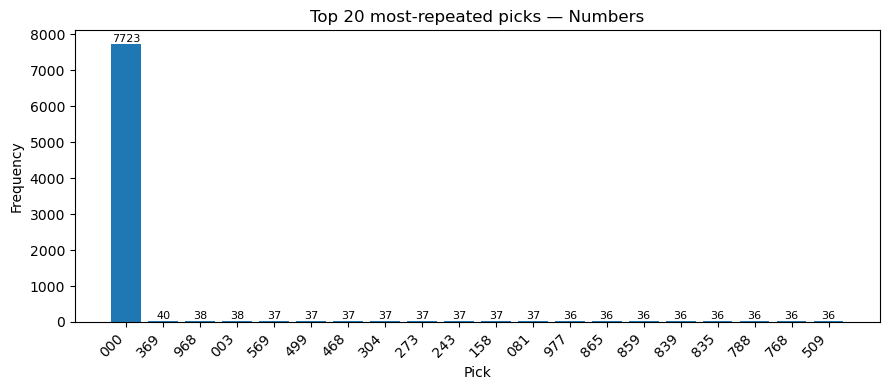

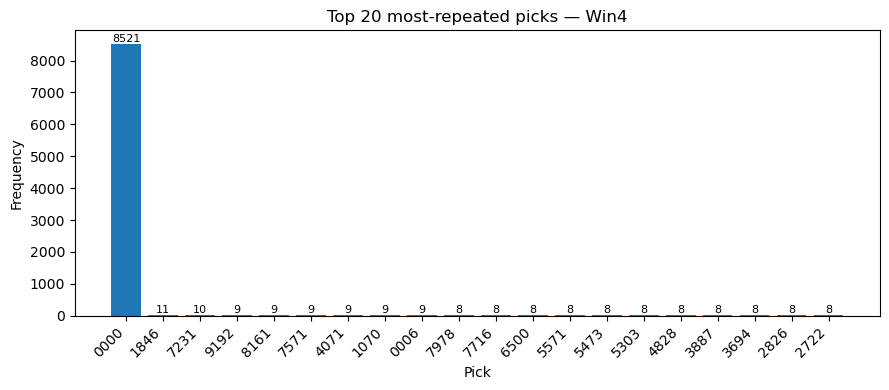

In [20]:
def top_picks_by_game_id(game_id: int, title: str, top_n: int = 20):
    df = pd.read_sql("""
        SELECT pick, COUNT(*) AS freq
        FROM fact_daily_draws
        WHERE game_id = ?
        GROUP BY pick
        ORDER BY freq DESC
        LIMIT ?
    """, con, params=[game_id, top_n])

    if df.empty:
        print(f"[skip] no rows for game_id={game_id}")
        return

    df["pick"] = df["pick"].astype(str)
    plt.figure(figsize=(9,4))
    bars = plt.bar(df["pick"], df["freq"])
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x()+b.get_width()/2, h+1, f"{int(h)}", ha="center", va="bottom", fontsize=8)
    plt.title(title)
    plt.xlabel("Pick"); plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

# Numbers = 6, Win4 = 7
top_picks_by_game_id(6, "Top 20 most-repeated picks — Numbers", top_n=20)
top_picks_by_game_id(7, "Top 20 most-repeated picks — Win4",    top_n=20)

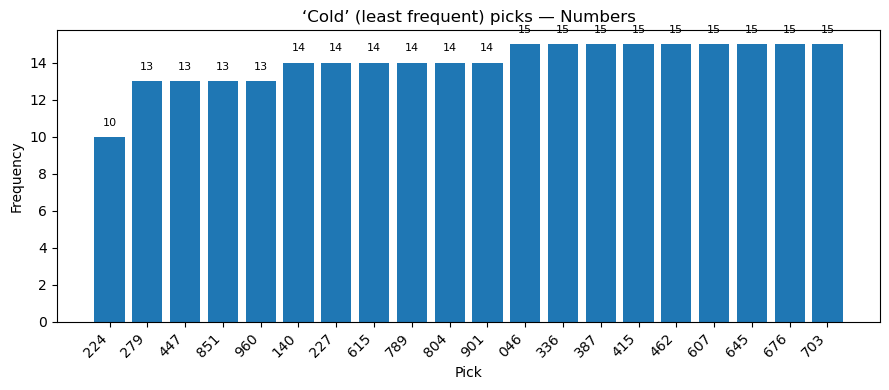

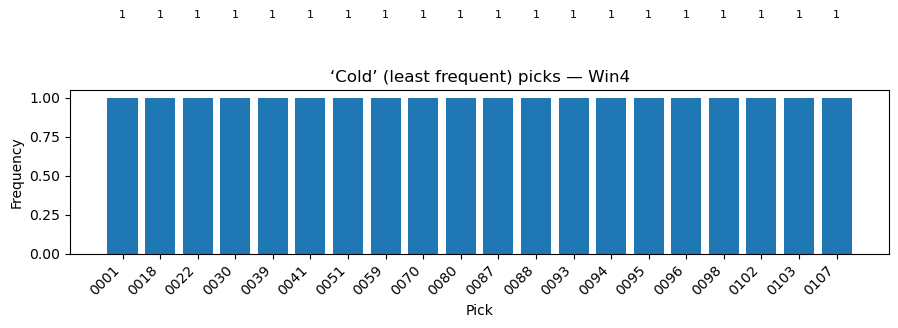

In [23]:
def cold_picks(game_id: int, title: str, top_n: int = 20):
    df = pd.read_sql("""
        SELECT pick, COUNT(*) AS freq
        FROM fact_daily_draws
        WHERE game_id = ?
        GROUP BY pick
        HAVING freq >= 1
        ORDER BY freq ASC, pick ASC
        LIMIT ?
    """, con, params=[game_id, top_n])

    if df.empty:
        print(f"[skip] no rows for game_id={game_id}"); return

    df["pick"] = df["pick"].astype(str)
    plt.figure(figsize=(9,4))
    bars = plt.bar(df["pick"], df["freq"])
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x()+b.get_width()/2, h+0.5, f"{int(h)}", ha="center", va="bottom", fontsize=8)
    plt.title(title)
    plt.xlabel("Pick"); plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

cold_picks(6, "‘Cold’ (least frequent) picks — Numbers", top_n=20)
cold_picks(7, "‘Cold’ (least frequent) picks — Win4",   top_n=20)

In [26]:
df_numbers["pick_int"] = df_numbers["pick"].astype(int)
df_win4["pick_int"] = df_win4["pick"].astype(int)

# Remove zero picks for clearer visualization
df_numbers_nz = df_numbers[df_numbers["pick_int"] != 0].copy()
df_win4_nz = df_win4[df_win4["pick_int"] != 0].copy()

print(f"Numbers draws (non-zero): {len(df_numbers_nz)} / {len(df_numbers)}")
print(f"Win4 draws (non-zero): {len(df_win4_nz)} / {len(df_win4)}")

Numbers draws (non-zero): 25087 / 32810
Win4 draws (non-zero): 24289 / 32810


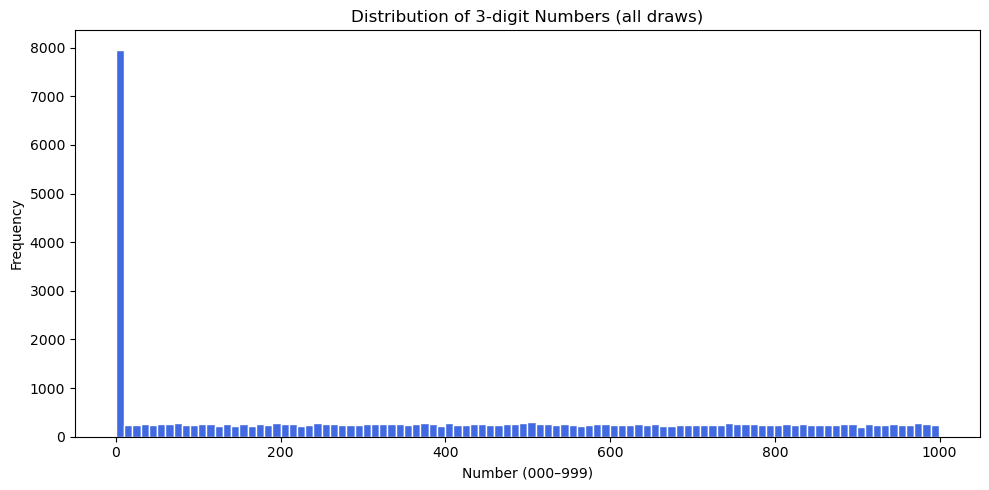

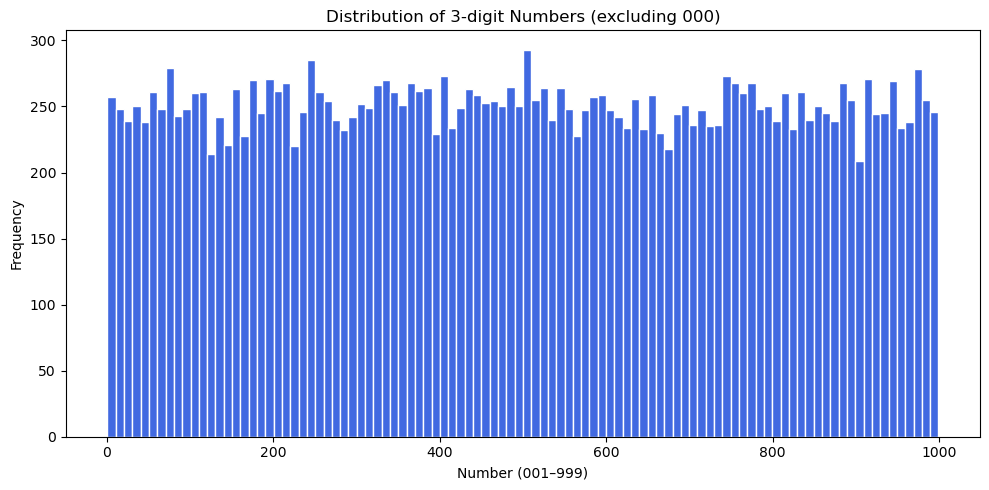

In [29]:
plt.figure(figsize=(10,5))
plt.hist(df_numbers["pick_int"], bins=100, color="royalblue", edgecolor="white")
plt.title("Distribution of 3-digit Numbers (all draws)")
plt.xlabel("Number (000–999)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.hist(df_numbers_nz["pick_int"], bins=100, color="royalblue", edgecolor="white")
plt.title("Distribution of 3-digit Numbers (excluding 000)")
plt.xlabel("Number (001–999)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

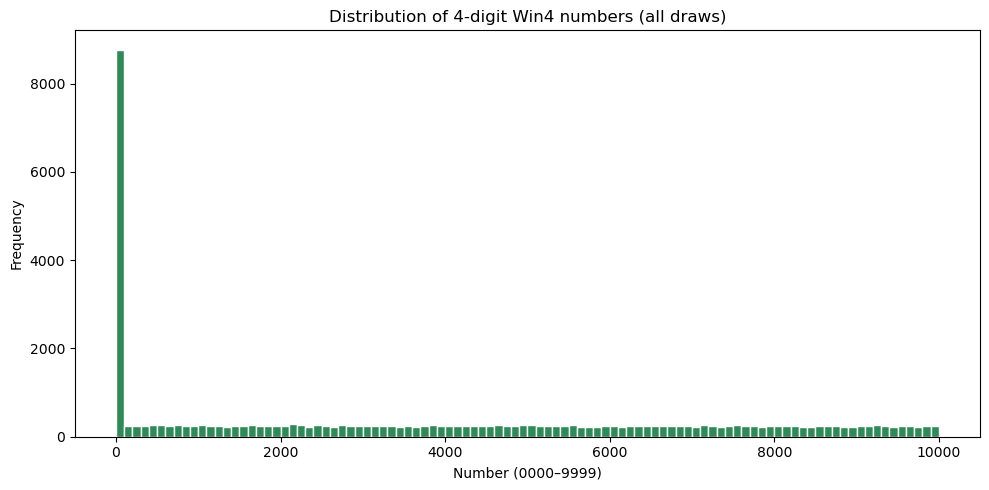

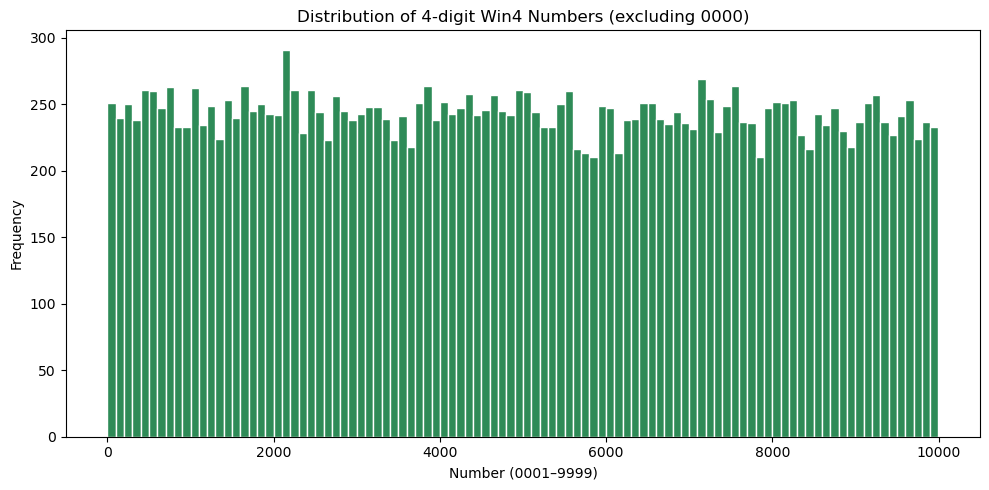

In [32]:
plt.figure(figsize=(10,5))
plt.hist(df_win4["pick_int"], bins=100, color="seagreen", edgecolor="white")
plt.title("Distribution of 4-digit Win4 numbers (all draws)")
plt.xlabel("Number (0000–9999)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
plt.hist(df_win4_nz["pick_int"], bins=100, color="seagreen", edgecolor="white")
plt.title("Distribution of 4-digit Win4 Numbers (excluding 0000)")
plt.xlabel("Number (0001–9999)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

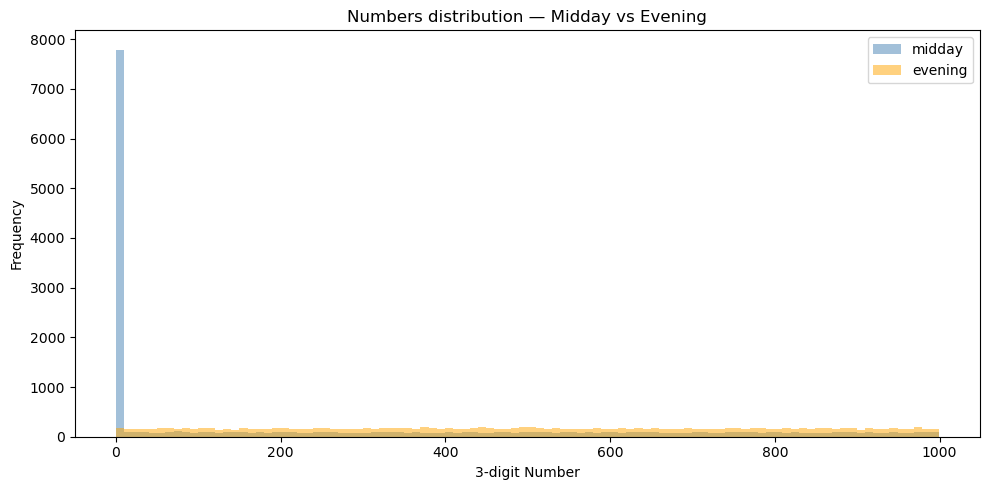

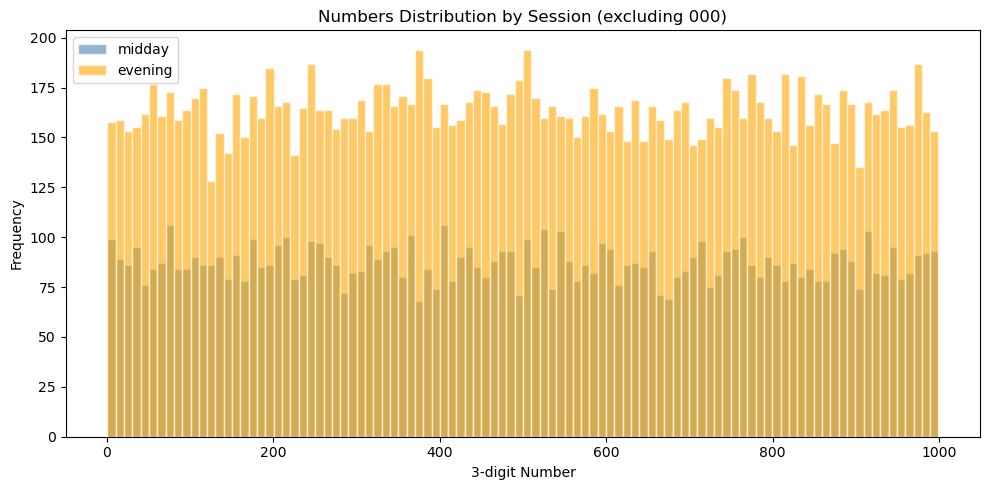

In [35]:
plt.figure(figsize=(10,5))
for sess, color in zip(["midday","evening"], ["steelblue","orange"]):
    plt.hist(df_numbers.loc[df_numbers["session"]==sess, "pick_int"], bins=100, 
             alpha=0.5, label=sess, color=color)
plt.title("Numbers distribution — Midday vs Evening")
plt.xlabel("3-digit Number")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
for sess, color in zip(["midday","evening"], ["steelblue","orange"]):
    plt.hist(df_numbers_nz.loc[df_numbers_nz["session"]==sess, "pick_int"],
             bins=100, alpha=0.6, label=sess, color=color, edgecolor="white")
plt.title("Numbers Distribution by Session (excluding 000)")
plt.xlabel("3-digit Number")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

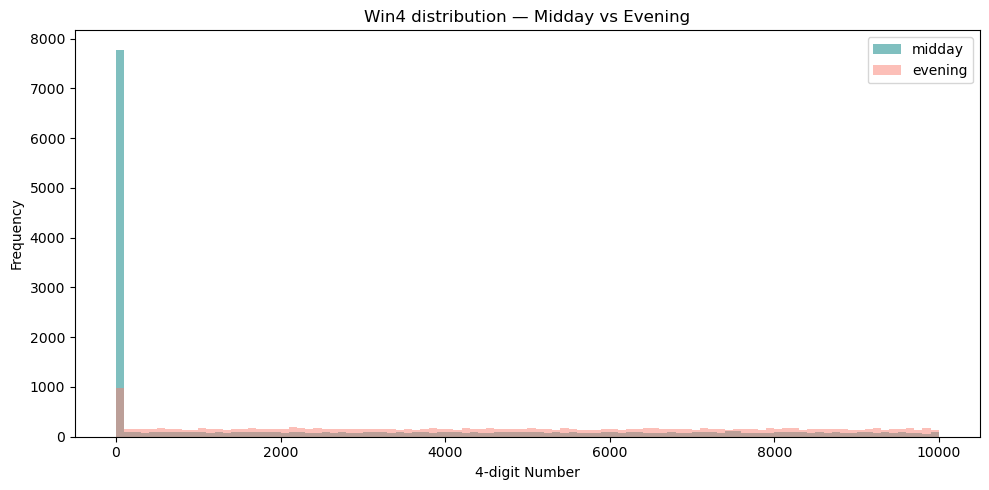

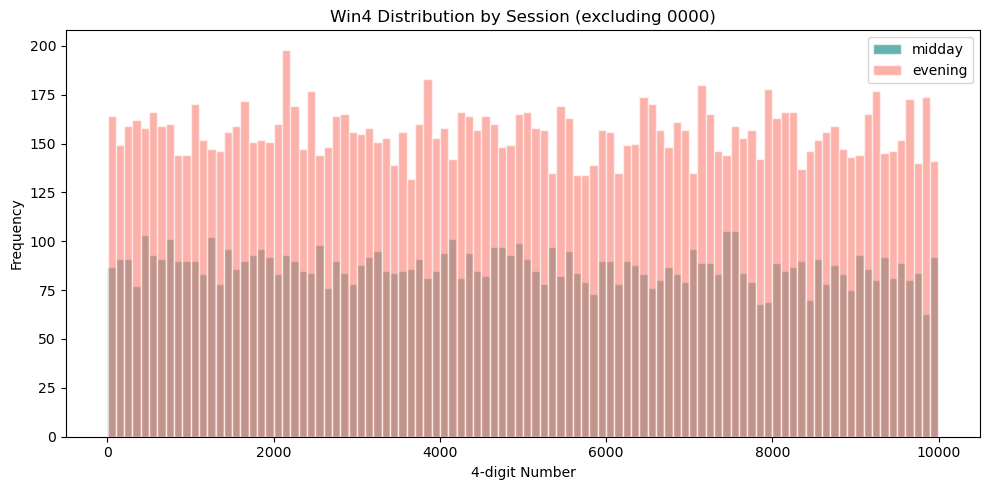

In [38]:
plt.figure(figsize=(10,5))
for sess, color in zip(["midday","evening"], ["teal","salmon"]):
    plt.hist(df_win4.loc[df_win4["session"]==sess, "pick_int"], bins=100, 
             alpha=0.5, label=sess, color=color)
plt.title("Win4 distribution — Midday vs Evening")
plt.xlabel("4-digit Number")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
for sess, color in zip(["midday","evening"], ["teal","salmon"]):
    plt.hist(df_win4_nz.loc[df_win4_nz["session"]==sess, "pick_int"],
             bins=100, alpha=0.6, label=sess, color=color, edgecolor="white")
plt.title("Win4 Distribution by Session (excluding 0000)")
plt.xlabel("4-digit Number")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
print("Numbers Game Stats:")
print(df_numbers["pick_int"].describe().apply(lambda x: format(x, ".2f")))
print("\nWin4 Game Stats:")
print(df_win4["pick_int"].describe().apply(lambda x: format(x, ".2f")))

Numbers Game Stats:
count    32810.00
mean       381.57
std        328.87
min          0.00
25%         20.00
50%        346.00
75%        670.00
max        999.00
Name: pick_int, dtype: object

Win4 Game Stats:
count    32810.00
mean      3670.31
std       3300.65
min          0.00
25%          0.00
50%       3185.50
75%       6575.00
max       9999.00
Name: pick_int, dtype: object


In [44]:
# Convert to datetime
df_numbers["draw_date"] = pd.to_datetime(df_numbers["draw_date"])
df_win4["draw_date"] = pd.to_datetime(df_win4["draw_date"])

# Filter only zero picks
zero_numbers = df_numbers[df_numbers["pick_int"] == 0].copy()
zero_win4 = df_win4[df_win4["pick_int"] == 0].copy()

# Group by month
zero_numbers["month"] = zero_numbers["draw_date"].dt.to_period("M")
zero_win4["month"] = zero_win4["draw_date"].dt.to_period("M")

freq_zero = (
    pd.DataFrame({
        "numbers_zero": zero_numbers.groupby("month").size(),
        "win4_zero": zero_win4.groupby("month").size()
    })
    .fillna(0)
    .astype(int)
    .reset_index()
)
freq_zero["month"] = freq_zero["month"].astype(str)
freq_zero.tail(10)


,month,numbers_zero,win4_zero
272,2012-01,1,0
273,2013-04,1,0
274,2015-03,1,0
275,2016-05,1,0
276,2016-11,1,0
277,2019-01,1,0
278,2019-05,1,0
279,2023-07,1,0
280,2024-05,1,0
281,2024-12,1,0


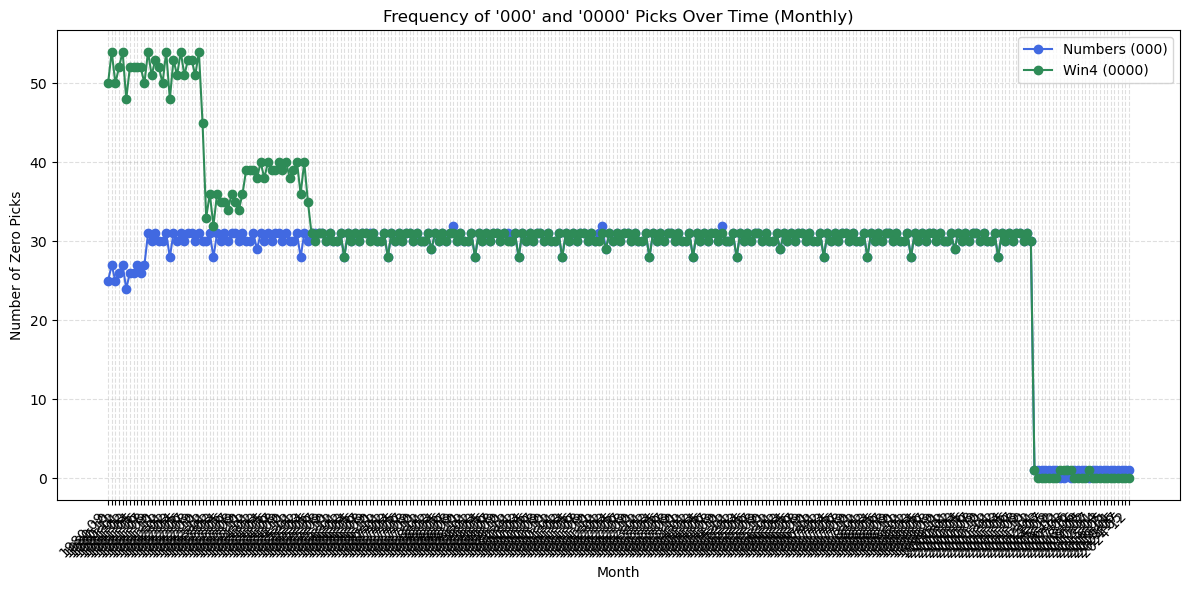

In [47]:
plt.figure(figsize=(12,6))
plt.plot(freq_zero["month"], freq_zero["numbers_zero"], label="Numbers (000)", color="royalblue", marker="o")
plt.plot(freq_zero["month"], freq_zero["win4_zero"], label="Win4 (0000)", color="seagreen", marker="o")

plt.title("Frequency of '000' and '0000' Picks Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Zero Picks")
plt.legend()
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [50]:
zero_yearly = (
    pd.DataFrame({
        "numbers_zero": zero_numbers.groupby(zero_numbers["draw_date"].dt.year).size(),
        "win4_zero": zero_win4.groupby(zero_win4["draw_date"].dt.year).size()
    })
    .fillna(0)
    .astype(int)
    .rename_axis("year")
    .reset_index()
)
display(zero_yearly)

,year,numbers_zero,win4_zero
0,1980,103,206
1,1981,335,620
2,1982,364,600
3,1983,364,427
4,1984,365,469
5,1985,365,395
6,1986,365,364
7,1987,364,364
8,1988,366,365
9,1989,365,364


In [57]:
numbers_df = pd.read_sql("""
SELECT draw_date, pick, session_id
FROM fact_daily_draws
WHERE game_id = 6   -- Numbers
""", con)

# Add sorted & digit-set versions
numbers_df["sorted_pick"] = numbers_df["pick"].apply(lambda x: "".join(sorted(str(x))))
numbers_df["digit_set"] = numbers_df["pick"].apply(lambda x: ",".join(sorted(list(str(x)))))

numbers_df.head()

,draw_date,pick,session_id,sorted_pick,digit_set
0,1980-09-02,000,1,000,"0,0,0"
1,1980-09-02,255,2,255,"2,5,5"
2,1980-09-03,000,1,000,"0,0,0"
3,1980-09-03,905,2,059,"0,5,9"
4,1980-09-04,000,1,000,"0,0,0"


In [59]:
win4_df = pd.read_sql("""
SELECT draw_date, pick, session_id
FROM fact_daily_draws
WHERE game_id = 7   -- Win4
""", con)

win4_df["sorted_pick"] = win4_df["pick"].apply(lambda x: "".join(sorted(str(x))))
win4_df["digit_set"] = win4_df["pick"].apply(lambda x: ",".join(sorted(list(str(x)))))

win4_df.head()


,draw_date,pick,session_id,sorted_pick,digit_set
0,1980-09-02,0000,1,0000,"0,0,0,0"
1,1980-09-02,0000,2,0000,"0,0,0,0"
2,1980-09-03,0000,1,0000,"0,0,0,0"
3,1980-09-03,0000,2,0000,"0,0,0,0"
4,1980-09-04,0000,1,0000,"0,0,0,0"


In [61]:
numbers_df["sorted_pick"].value_counts().head(20)

sorted_pick
000    7723
018     179
047     178
347     177
458     175
578     174
125     173
348     172
237     170
369     170
017     169
479     168
568     168
159     167
234     167
034     166
059     166
368     165
489     165
025     165
Name: count, dtype: int64

In [63]:
numbers_df["digit_set"].value_counts().head(20)

digit_set
0,0,0    7723
0,1,8     179
0,4,7     178
3,4,7     177
4,5,8     175
5,7,8     174
1,2,5     173
3,4,8     172
2,3,7     170
3,6,9     170
0,1,7     169
4,7,9     168
5,6,8     168
1,5,9     167
2,3,4     167
0,3,4     166
0,5,9     166
3,6,8     165
4,8,9     165
0,2,5     165
Name: count, dtype: int64

In [65]:
numbers = pd.read_sql("""
SELECT draw_date, pick
FROM fact_daily_draws
WHERE game_id = 6   -- Numbers
""", con)

numbers["pick"] = numbers["pick"].astype(str).str.zfill(3)
numbers["sorted_pick"] = numbers["pick"].apply(lambda x: "".join(sorted(x)))
numbers["digit_set"] = numbers["sorted_pick"]
numbers["d1"] = numbers["pick"].str[0]
numbers["d2"] = numbers["pick"].str[1]
numbers["d3"] = numbers["pick"].str[2]

numbers.head()

,draw_date,pick,sorted_pick,digit_set,d1,d2,d3
0,1980-09-02,000,000,000,0,0,0
1,1980-09-02,255,255,255,2,5,5
2,1980-09-03,000,000,000,0,0,0
3,1980-09-03,905,059,059,9,0,5
4,1980-09-04,000,000,000,0,0,0


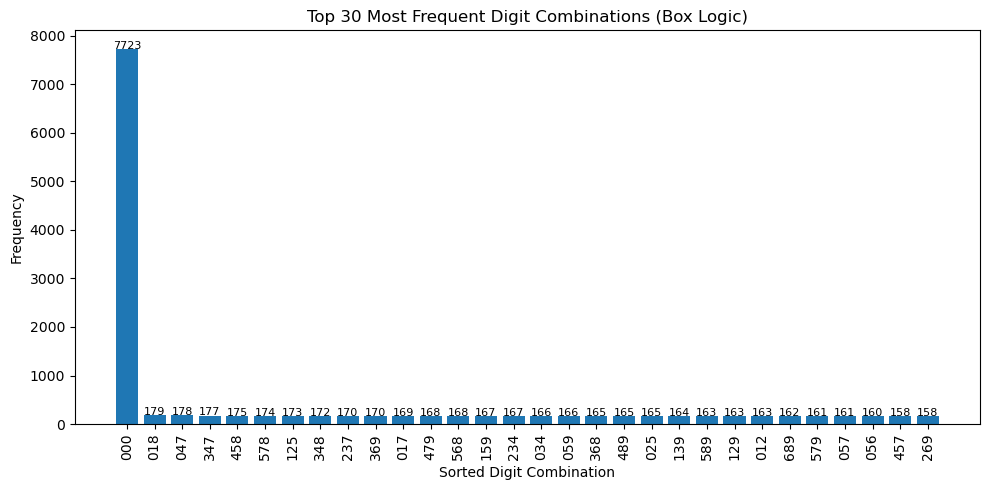

In [67]:
sorted_freq = numbers["sorted_pick"].value_counts().head(30)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
bars = plt.bar(sorted_freq.index, sorted_freq.values)

for b in bars:
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2, h+1, str(int(h)),
             ha="center", fontsize=8)

plt.title("Top 30 Most Frequent Digit Combinations (Box Logic)")
plt.xlabel("Sorted Digit Combination")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [69]:
from collections import Counter

pairs = []

for s in numbers["sorted_pick"]:
    d = list(s)
    pairs.append(tuple(sorted([d[0], d[1]])))
    pairs.append(tuple(sorted([d[1], d[2]])))
    pairs.append(tuple(sorted([d[0], d[2]])))

pair_counts = Counter(pairs)
pair_df = pd.DataFrame(pair_counts.items(), columns=["pair", "freq"]).sort_values("freq", ascending=False)

pair_df.head(20)


,pair,freq
0,"(0, 0)",23848
22,"(3, 4)",1591
3,"(0, 5)",1581
43,"(5, 8)",1577
33,"(5, 7)",1577
52,"(1, 9)",1559
32,"(4, 9)",1554
50,"(4, 8)",1545
11,"(0, 2)",1542
25,"(6, 9)",1542


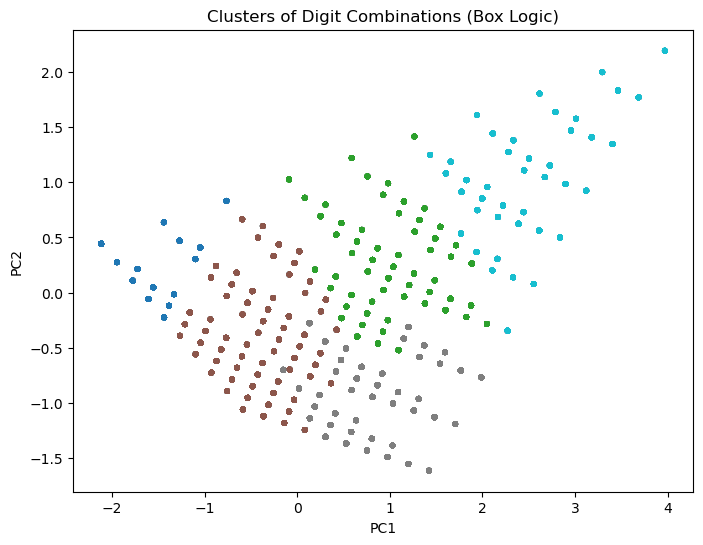

In [81]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = numbers["sorted_pick"].apply(lambda x: [int(x[0]), int(x[1]), int(x[2])])
X = np.array(list(X))

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

numbers["cluster"] = labels

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(coords[:,0], coords[:,1], c=labels, cmap="tab10", s=10)
plt.title("Clusters of Digit Combinations (Box Logic)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


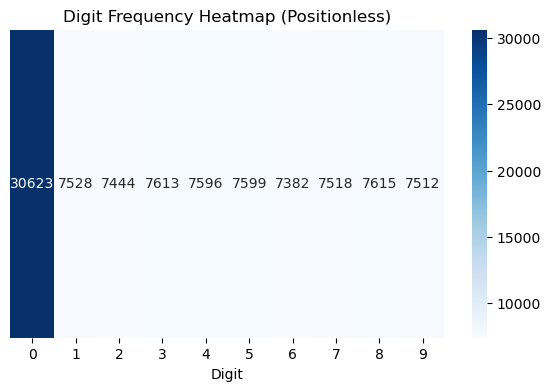

In [77]:
import seaborn as sns

digit_counts = pd.Series(list("".join(numbers["pick"])), name="digit").value_counts().sort_index()

plt.figure(figsize=(7,4))
sns.heatmap(digit_counts.values.reshape(1,-1), annot=True, fmt="d",
            cmap="Blues", xticklabels=list(range(10)))
plt.title("Digit Frequency Heatmap (Positionless)")
plt.yticks([], [])
plt.xlabel("Digit")
plt.show()


In [83]:
latest = numbers["draw_date"].max()

last_year = numbers[numbers["draw_date"] >= latest - pd.Timedelta(days=365)]
last_month = numbers[numbers["draw_date"] >= latest - pd.Timedelta(days=30)]


TypeError: unsupported operand type(s) for -: 'str' and 'Timedelta'